# 7. 複数の目的変数を予測し、複数のサンプルをBayesian Optimizationにより抽出する

- 複数の目的変数について GPR で PI/PTR を計算し、`log prob` の和を最大化する候補を **設定した回数だけ** 連続選抜する
- 選抜時の予測値は `bo_selected_summary` に記録され、最後に表・構造式で確認できる

---

## ユーザー設定（ここを編集してください）
**以下のセルで目的変数などを指定してください。1.Preparation.ipynb と同じ設定を使用します。**

## ライブラリ読み込み

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import norm
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_predict
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import WhiteKernel, RBF, ConstantKernel, Matern, DotProduct
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw

np.random.seed(1234)

## 学習データとテストデータ読み込み
`6.BO_multi-sample.ipynb` と同じデータソースを使い、目的変数2つ（発光波長・PLQY）と記述子を準備

In [ ]:
# ============================================================
# ユーザー設定: 1.Preparation.ipynb と同じ設定を使用
# ============================================================

# 目的変数の列名（リストで複数指定可能）
TARGET_COLS = ["Emission max (nm)", "Quantum yield"]

# 目的変数の短縮名（列名に使用、TARGET_COLSと同じ順序で指定）
# Noneの場合は自動生成（target_0, target_1, ...）
TARGET_SHORT_NAMES = None  # 例: ["emission", "plqy"]

# 使用する記述子のタイプ
DESCRIPTOR_TYPE = "rdkit"  # "rdkit" or "mordred_2d" or "mordred_3d" or "fp"

# SMILES列の名前
SMILES_COL = "Chromophore"

# PTR（Probability of Target Range）の範囲設定
# 目的変数ごとに [min, max] を指定
PTR_RANGES = {
    "Emission max (nm)": [600, 1000],
    "Quantum yield": [0.5, 1.0],
}

# ============================================================
# 短縮名の自動生成
if TARGET_SHORT_NAMES is None:
    TARGET_SHORT_NAMES = [f"target_{i}" for i in range(len(TARGET_COLS))]

print(f"目的変数: {TARGET_COLS}")
print(f"短縮名: {TARGET_SHORT_NAMES}")
print(f"記述子タイプ: {DESCRIPTOR_TYPE}")
print(f"PTR範囲: {PTR_RANGES}")

In [2]:
# データ読み込み（設定変数を使用）
dataset_train = pd.read_csv("../data/dataset_train.csv", index_col=0)
target = dataset_train[TARGET_COLS]

if DESCRIPTOR_TYPE == "rdkit":
    des_train = pd.read_csv("outputs/descriptors/rdkit/X_train_rdkit_processed.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/rdkit/X_test_rdkit_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "mordred_2d":
    des_train = pd.read_csv("outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "mordred_3d":
    des_train = pd.read_csv("outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "fp":
    des_train = pd.read_csv("outputs/descriptors/fp/X_train_fp.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/fp/X_test_fp.csv", index_col=0)
else:
    raise ValueError(f"未知の DESCRIPTOR_TYPE: {DESCRIPTOR_TYPE}")

# 目的変数と記述子を結合
dataset = target.join(des_train, how="inner")

# テストデータ
x_prediction = des_test.copy()

print(f"dataset: {dataset.shape}")
print(f"x_prediction: {x_prediction.shape}")

dataset: (13132, 208)
x_prediction: (7104, 206)


In [3]:
#（任意）学習データを間引いて試行時間を短縮するテンプレート。既定はコメントアウト。必要ならコメント解除してから実行。

# 学習データを間引く
MAX_TRAIN_SAMPLES = 2000
RANDOM_STATE = 1234

if len(dataset) > MAX_TRAIN_SAMPLES:
    dataset = dataset.sample(n=MAX_TRAIN_SAMPLES, random_state=RANDOM_STATE)
    print(f"dataset を {MAX_TRAIN_SAMPLES} 件に間引きました: {dataset.shape}")
else:
    print(f"dataset 件数が {MAX_TRAIN_SAMPLES} 以下のため間引きなし: {dataset.shape}")

dataset を 2000 件に間引きました: (2000, 208)


## BO設定
- `sample_program_05_04_bayesian_optimization_multi_y_multi_sample.py` に合わせて、複数目的・複数サンプル選択の設定を行う
- 長波長の発光かつ高い量子収率の材料を探す

In [4]:
# 候補数
number_of_selecting_samples = 20

# 回帰手法
regression_method = "gpr_one_kernel"  # "gpr_one_kernel" or "gpr_kernels"

# カーネル番号、gpr_one_kernel のときに使用
kernel_number = 7

# CV の分割: "kfold" または "loo"（enable_cv_metrics および regression_method=="gpr_kernels" で使用）
# サンプルが少ないときはloo（leave one out）を使用したほうが良い
cv_strategy = "kfold"  # "kfold" or "loo"

# kfold のときの分割数（loo のときは未使用）
fold_number = 5

# True: CV指標を計算 / False: CV指標計算をスキップして高速化
enable_cv_metrics = True

# 「学習データの極値から、標準偏差の何割ぶん緩めるか」という係数で、0.01 なら 標準偏差の 1% ぶんだけ閾値をずらすイメージ
relaxation = 0.01

# ルール:
# row 0: target_type (1=maximize, -1=minimize, 0=target range)
# row 1: lower_limit (target_type==0 のとき有効)
# row 2: upper_limit (target_type==0 のとき有効)
# 列は目的変数に対応

# 獲得関数: PIかPTRを選ぶ
acquisition_mode = "PTR" # PI or PTR

if acquisition_mode == 'PI':
    settings = pd.DataFrame(
    {
        "Emission max (nm)": [1, 0, 0],  # PI(1)
        "Quantum yield": [0, 0.5, 1.0],  # PTR(0), range=[0.5, 1.0]
    },
    index=["target_type", "lower_limit", "upper_limit"],
)
else:
    settings = pd.DataFrame(
    {
        "Emission max (nm)": [0, 600, 900],  # PTR(0), range=[600, 900]
        "Quantum yield": [0, 0.5, 1.0],  # PTR(0), range=[0.5, 1.0]
    },
    index=["target_type", "lower_limit", "upper_limit"],
)

# 保存 CSV のファイル名接尾辞（回帰手法 + 獲得関数モード PI/PTR）
csv_name_suffix = f"{regression_method}_{acquisition_mode}"

display(settings)

,Emission max (nm),Quantum yield
target_type,0,0.0
lower_limit,600,0.5
upper_limit,900,1.0


In [5]:
# 目的変数の個数
number_of_y_variables = settings.shape[1]
if number_of_y_variables != (dataset.shape[1] - x_prediction.shape[1]):
    raise Exception(
        "training dataset と x_prediction と settings の目的変数・説明変数の数を確認してください。"
    )

for i in range(number_of_y_variables):
    if settings.iloc[0, i] == 0 and settings.iloc[1, i] >= settings.iloc[2, i]:
        raise Exception("settings の lower_limit は upper_limit より小さい必要があります。")

# データ分割
y = dataset.iloc[:, :number_of_y_variables]
x = dataset.iloc[:, number_of_y_variables:]

# 標準偏差が 0 の特徴量を除去
deleting_variables = x.columns[x.std() == 0]
x = x.drop(deleting_variables, axis=1)
x_prediction = x_prediction.drop(deleting_variables, axis=1)

print("y:", y.shape)
print("x:", x.shape)
print("x_prediction:", x_prediction.shape)

y: (2000, 2)
x: (2000, 200)
x_prediction: (7104, 200)


In [6]:
# GPR で比較するカーネル候補を一覧定義する（単一カーネル番号指定や探索モードで利用）。

kernels = [
    ConstantKernel() * DotProduct() + WhiteKernel(),
    ConstantKernel() * RBF() + WhiteKernel(),
    ConstantKernel() * RBF() + WhiteKernel() + ConstantKernel() * DotProduct(),
    ConstantKernel() * RBF(np.ones(x.shape[1])) + WhiteKernel(),
    ConstantKernel() * RBF(np.ones(x.shape[1])) + WhiteKernel() + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=1.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=1.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=0.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=0.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=2.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=2.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
]

## 複数目的・複数サンプル BO 実行
- 各目的変数ごとにGPRモデルを作成し、`settings` に応じて目標達成確率（PIまたはPTR）を計算
- 2目的の確率の対数和を最大化する候補を順次選択する

In [7]:
# Utility

# 保存先
save_dir = "outputs/result/bo_multi_y"
os.makedirs(save_dir, exist_ok=True)

def calc_rmse(y_true, y_pred):
    """
    sklearn のバージョン差異を避けるため RMSE を手計算する。
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))


def _make_cv_splitter():
    """cv_strategy に応じて cross_val_predict 用の分割器を返す。"""
    if cv_strategy == "loo":
        return LeaveOneOut()
    if cv_strategy == "kfold":
        return KFold(n_splits=fold_number, random_state=9, shuffle=True)
    raise ValueError('cv_strategy は "kfold" または "loo" を指定してください。')


def select_model_for_target(autoscaled_x, autoscaled_y_col, y_col, mean_y, std_y):
    """
    目的変数1本分のGPRモデルを作る。
    """
    if regression_method == "gpr_one_kernel":
        return GaussianProcessRegressor(alpha=0, kernel=kernels[kernel_number])

    if regression_method == "gpr_kernels":
        cross_validation = _make_cv_splitter()
        r2cvs = []
        for kernel in kernels:
            model_tmp = GaussianProcessRegressor(alpha=0, kernel=kernel)
            estimated_y_in_cv = np.ndarray.flatten(
                cross_val_predict(model_tmp, autoscaled_x, autoscaled_y_col, cv=cross_validation)
            )
            estimated_y_in_cv = estimated_y_in_cv * std_y + mean_y
            r2cvs.append(r2_score(y_col, estimated_y_in_cv))
        optimal_kernel_number = np.where(r2cvs == np.max(r2cvs))[0][0]
        return GaussianProcessRegressor(alpha=0, kernel=kernels[optimal_kernel_number])

    raise ValueError(f"未知の回帰手法です: {regression_method}")

def calc_probability_from_settings(y_number, y_col, y_pred, y_std):
    """
    settings の定義に従って目標達成確率を計算する。
    """
    target_type = settings.iloc[0, y_number]

    if target_type == 1:  # PI: 最大化
        prob = 1 - norm.cdf(
            y_col.max() + y_col.std() * relaxation,
            loc=y_pred,
            scale=y_std,
        )
    elif target_type == -1:  # 最小化
        prob = norm.cdf(
            y_col.min() - y_col.std() * relaxation,
            loc=y_pred,
            scale=y_std,
        )
    elif target_type == 0:  # PTR: 範囲指定
        prob = norm.cdf(
            settings.iloc[2, y_number],
            loc=y_pred,
            scale=y_std,
        ) - norm.cdf(
            settings.iloc[1, y_number],
            loc=y_pred,
            scale=y_std,
        )
    else:
        raise ValueError("settings の target_type は 1, -1, 0 のいずれかで指定してください。")

    prob[y_std <= 0] = 0
    return prob

In [8]:
# --- 初期化: 選抜結果の入れ物 ---
# next_samples: 選ばれた候補の記述子のみ（実験候補リスト）
next_samples = pd.DataFrame([], columns=x_prediction.columns)
selected_summary_records = []

# std / 達成確率の列名（y の列順: 1列目=発光、2列目=PLQY）。settings の target_type を PI/PTR として列名に反映。
# 目的変数の名前をここで指定
_short_targets = TARGET_SHORT_NAMES
if number_of_y_variables != len(_short_targets):
    raise ValueError(f"TARGET_SHORT_NAMES の数({len(_short_targets)})が目的変数の数({number_of_y_variables})と一致しません。")

std_columns = [f"std_of_{name}" for name in _short_targets]

prob_columns = []
for i in range(number_of_y_variables):
    tt = int(settings.iloc[0, i])
    name = _short_targets[i]
    if tt == 0:
        prob_columns.append(f"PTR_{name}")
    elif tt == 1:
        prob_columns.append(f"PI_{name}")
    else:
        prob_columns.append(f"PI_min_{name}")

# ラウンドごとの BO（number_of_selecting_samples 回）学習
for sample_number in range(number_of_selecting_samples):
    # 毎ラウンド、学習データ基準でオートスケール
    autoscaled_y = (y - y.mean()) / y.std()
    autoscaled_x = (x - x.mean()) / x.std()
    autoscaled_x_prediction = (x_prediction - x.mean()) / x.std()

    mean_of_y = y.mean()
    std_of_y = y.std()

    # 2目的分の予測値・不確かさ・確率を格納
    estimated_y_prediction_all = np.zeros((x_prediction.shape[0], number_of_y_variables))
    std_of_estimated_y_prediction_all = np.zeros((x_prediction.shape[0], number_of_y_variables))
    probabilities_prediction_all = np.zeros((x_prediction.shape[0], number_of_y_variables))

    # 目的変数ごとに GPR を学習し、候補への予測と獲得「成分」を計算
    for y_number in range(number_of_y_variables):
        y_col = y.iloc[:, y_number]
        model = select_model_for_target(
            autoscaled_x,
            autoscaled_y.iloc[:, y_number],
            y_col,
            mean_of_y.iloc[y_number],
            std_of_y.iloc[y_number],
        )
        model.fit(autoscaled_x, autoscaled_y.iloc[:, y_number])

        # 1ラウンド目のみ学習性能を確認
        if sample_number == 0:
            autoscaled_estimated_y, _ = model.predict(autoscaled_x, return_std=True)
            estimated_y = autoscaled_estimated_y * y_col.std() + y_col.mean()
            print(f"[{TARGET_COLS[y_number]}] r^2 for training data:", r2_score(y_col, estimated_y))
            print(f"[{TARGET_COLS[y_number]}] RMSE for training data:", calc_rmse(y_col, estimated_y))
            print(f"[{TARGET_COLS[y_number]}] MAE for training data:", mean_absolute_error(y_col, estimated_y))

            if enable_cv_metrics:
                # cv_strategy: "kfold"（fold_number 分割）または "loo"（n サンプル分割・重い）
                cross_validation = _make_cv_splitter()
                autoscaled_estimated_y_in_cv = cross_val_predict(
                    model, autoscaled_x, autoscaled_y.iloc[:, y_number], cv=cross_validation
                )
                estimated_y_in_cv = autoscaled_estimated_y_in_cv * y_col.std() + y_col.mean()
                print(f"[{TARGET_COLS[y_number]}] r^2 in CV ({cv_strategy}):", r2_score(y_col, estimated_y_in_cv))
                print(f"[{TARGET_COLS[y_number]}] RMSE in CV ({cv_strategy}):", calc_rmse(y_col, estimated_y_in_cv))
                print(f"[{TARGET_COLS[y_number]}] MAE in CV ({cv_strategy}):", mean_absolute_error(y_col, estimated_y_in_cv))
            else:
                print(f"[{TARGET_COLS[y_number]}] CV metrics: skipped (enable_cv_metrics=False)")

        # 候補全体に対する予測
        y_pred, y_pred_std = model.predict(autoscaled_x_prediction, return_std=True)
        y_pred = y_pred * y_col.std() + y_col.mean()
        y_pred_std = y_pred_std * y_col.std()

        prob = calc_probability_from_settings(y_number, y_col, y_pred, y_pred_std)

        estimated_y_prediction_all[:, y_number] = y_pred
        std_of_estimated_y_prediction_all[:, y_number] = y_pred_std
        probabilities_prediction_all[:, y_number] = prob

    # 複数目的の同時最適化: log(prob) の和を最大化
    sum_of_log_probabilities = np.log(probabilities_prediction_all).sum(axis=1)
    sum_of_log_probabilities[np.isneginf(sum_of_log_probabilities)] = -10**100

    estimated_y_prediction_all = pd.DataFrame(estimated_y_prediction_all, index=x_prediction.index, columns=TARGET_COLS)
    std_of_estimated_y_prediction_all = pd.DataFrame(
        std_of_estimated_y_prediction_all, index=x_prediction.index, columns=std_columns
    )
    probabilities_prediction_all = pd.DataFrame(
        probabilities_prediction_all, index=x_prediction.index, columns=prob_columns
    )
    sum_of_log_probabilities = pd.DataFrame(sum_of_log_probabilities, index=x_prediction.index, columns=["sum_of_log_probabilities"])

    if sample_number == 0:
        estimated_y_prediction_all.to_csv(f"{save_dir}/estimated_y_prediction_multi_y_{csv_name_suffix}.csv")
        std_of_estimated_y_prediction_all.to_csv(f"{save_dir}/estimated_y_prediction_multi_y_std_{csv_name_suffix}.csv")
        probabilities_prediction_all.to_csv(f"{save_dir}/probabilities_prediction_multi_y_{csv_name_suffix}.csv")
        sum_of_log_probabilities.to_csv(f"{save_dir}/sum_of_log_probabilities_prediction_multi_y_{csv_name_suffix}.csv")

    selected_idx = sum_of_log_probabilities["sum_of_log_probabilities"].idxmax()

    # 選抜ラウンド当時の予測・不確かさ・PTR を記録（後で display / CSV 用）
    y0, y1 = TARGET_COLS[0], TARGET_COLS[1]
    s0, s1 = std_columns[0], std_columns[1]
    pr0, pr1 = prob_columns[0], prob_columns[1]
    p0 = probabilities_prediction_all.loc[selected_idx, pr0]
    p1 = probabilities_prediction_all.loc[selected_idx, pr1]
    log_sum = np.log(p0) + np.log(p1)
    
    if np.isneginf(log_sum):
        log_sum = -10**100
    selected_summary_records.append(
        {
            "tag": selected_idx,
            y0: estimated_y_prediction_all.loc[selected_idx, y0],
            y1: estimated_y_prediction_all.loc[selected_idx, y1],
            s0: std_of_estimated_y_prediction_all.loc[selected_idx, s0],
            s1: std_of_estimated_y_prediction_all.loc[selected_idx, s1],
            pr0: p0,
            pr1: p1,
            "joint_target_prob_indep": p0 * p1,
            "sum_log_target_prob": log_sum,
        }
    )

    # 次候補を保存し、擬似的に学習データへ追加
    next_samples = pd.concat([next_samples, x_prediction.loc[[selected_idx]]], axis=0)
    x = pd.concat([x, x_prediction.loc[[selected_idx]]], axis=0)
    y = pd.concat([y, estimated_y_prediction_all.loc[[selected_idx]]], axis=0)
    x_prediction = x_prediction.drop(selected_idx, axis=0)

    print(f"sample number : {sample_number + 1} / {number_of_selecting_samples}")

# next_samples … 選抜候補の記述子のみ（実験設計・記述子パイプライン向け）
next_samples.to_csv(f"{save_dir}/next_samples_bo_multi_y_{csv_name_suffix}.csv")

# bo_selected_summary … 各ラウンドの予測・達成確率・log 確率和（実務で見る表）
bo_selected_summary = pd.DataFrame(selected_summary_records).set_index("tag")

# SMILES を dataset_test から 1 回だけ結合してから保存
dataset_test = pd.read_csv("../data/dataset_test.csv", index_col=0)
bo_selected_summary[SMILES_COL] = dataset_test.loc[
    bo_selected_summary.index, SMILES_COL
].astype(str)

bo_selected_summary.to_csv(f"{save_dir}/bo_selected_summary_multi_y_{csv_name_suffix}.csv")

[Emission max (nm)] r^2 for training data: 0.955943101985867
[Emission max (nm)] RMSE for training data: 19.467616800084468
[Emission max (nm)] MAE for training data: 13.219958089761958
[Emission max (nm)] r^2 in CV (kfold): 0.713488236196604
[Emission max (nm)] RMSE in CV (kfold): 49.645176635029365
[Emission max (nm)] MAE in CV (kfold): 35.658715660862164
[Quantum yield] r^2 for training data: 0.8511053673006392
[Quantum yield] RMSE for training data: 0.11883679776139555
[Quantum yield] MAE for training data: 0.08993172087946744
[Quantum yield] r^2 in CV (kfold): 0.3619414042173419
[Quantum yield] RMSE in CV (kfold): 0.24600373508981802
[Quantum yield] MAE in CV (kfold): 0.19481575243526542
sample number : 1 / 20
sample number : 2 / 20
sample number : 3 / 20
sample number : 4 / 20
sample number : 5 / 20
sample number : 6 / 20
sample number : 7 / 20
sample number : 8 / 20
sample number : 9 / 20
sample number : 10 / 20
sample number : 11 / 20
sample number : 12 / 20
sample number : 13 

## 結果確認

In [9]:
# 選択された次サンプルと、2目的の予測結果（平均・標準偏差・達成確率）を表示します。
display(next_samples.head(number_of_selecting_samples))
display(estimated_y_prediction_all.head())
display(std_of_estimated_y_prediction_all.head())
display(probabilities_prediction_all.head())

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
14758,15.348305,15.348305,0.152983,-0.450881,0.060129,14.073171,1095.39,1020.798,1094.544517,420,...,0,0,0,0,0,0,0,0,2,0
14763,15.348305,15.348305,0.152983,-0.450881,0.060129,14.073171,1095.39,1020.798,1094.544517,420,...,0,0,0,0,0,0,0,0,2,0
3186,17.058038,17.058038,0.471133,-4.220648,0.202782,15.681818,586.539,549.243,586.307934,222,...,0,0,0,0,0,0,0,0,0,0
277,12.300574,12.300574,0.038984,-0.038984,0.417401,11.416667,318.376,300.232,318.136828,120,...,0,0,0,0,0,0,0,0,0,0
278,12.300574,12.300574,0.038984,-0.038984,0.417401,11.416667,318.376,300.232,318.136828,120,...,0,0,0,0,0,0,0,0,0,0
279,12.300574,12.300574,0.038984,-0.038984,0.417401,11.416667,318.376,300.232,318.136828,120,...,0,0,0,0,0,0,0,0,0,0
280,12.300574,12.300574,0.038984,-0.038984,0.417401,11.416667,318.376,300.232,318.136828,120,...,0,0,0,0,0,0,0,0,0,0
281,12.300574,12.300574,0.038984,-0.038984,0.417401,11.416667,318.376,300.232,318.136828,120,...,0,0,0,0,0,0,0,0,0,0
282,12.300574,12.300574,0.038984,-0.038984,0.417401,11.416667,318.376,300.232,318.136828,120,...,0,0,0,0,0,0,0,0,0,0
283,12.300574,12.300574,0.038984,-0.038984,0.417401,11.416667,318.376,300.232,318.136828,120,...,0,0,0,0,0,0,0,0,0,0


,Emission max (nm),Quantum yield
Tag,,
1,443.470947,0.256887
2,427.337593,0.194768
3,537.243599,0.370448
4,454.563515,0.300568
5,454.563515,0.300568


,std_of_emission,std_of_plqy
Tag,,
1,52.754839,0.265709
2,55.773582,0.273804
3,80.908945,0.318016
4,57.185974,0.278461
5,57.185974,0.278461


,PTR_emission,PTR_plqy
Tag,,
1,0.001503,0.177525
2,0.000981,0.130836
3,0.218976,0.317994
4,0.005492,0.230930
5,0.005492,0.230930


## 選抜ラウンド当時の指標

`bo_selected_summary` は、BO ループ内で **そのラウンドで分子が選ばれた直後** に記録した予測平均・GPR 標準偏差・目標達成確率（`settings` に応じて PI または PTR）・log 確率和（全ラウンド終了後の再学習による値ではないので注意）。

In [10]:
# ループ内で蓄積した `bo_selected_summary` を確認する
display(bo_selected_summary.head(number_of_selecting_samples))

,Emission max (nm),Quantum yield,std_of_emission,std_of_plqy,PTR_emission,PTR_plqy,joint_target_prob_indep,sum_log_target_prob,Chromophore
tag,,,,,,,,,
14758,608.029649,0.716693,38.953175,0.215463,0.581658,0.748447,0.435340,-0.831628,CCCCN1C(=O)c2cc(Oc3ccc(C(C)(C)C)cc3)c3c4c(Oc5c...
14763,608.029893,0.716774,34.987563,0.196986,0.590763,0.789187,0.466222,-0.763092,CCCCN1C(=O)c2cc(Oc3ccc(C(C)(C)C)cc3)c3c4c(Oc5c...
3186,711.580130,0.465141,52.037534,0.263871,0.983846,0.426118,0.419234,-0.869325,CC1=CC(/C=C/c2ccc(N(C)C)cc2)=[N+]2C1=C(c1ccccc...
277,603.021723,0.641665,32.987359,0.186818,0.536493,0.748316,0.401466,-0.912632,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1
278,603.028646,0.641795,32.161170,0.182525,0.537513,0.756524,0.406642,-0.899822,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1
279,603.034436,0.641906,31.613159,0.179613,0.538234,0.762163,0.410222,-0.891056,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1
280,603.039432,0.642002,31.220034,0.177489,0.538778,0.766316,0.412874,-0.884613,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1
281,603.044031,0.642087,30.921635,0.175858,0.539210,0.769531,0.414939,-0.879625,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1
282,603.047831,0.642162,30.686137,0.174556,0.539559,0.772116,0.416602,-0.875624,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1


## BO で選択された分子の構造可視化
- `bo_selected_summary` の `Chromophore`（ループ終了時に `dataset_test` から付与済み）と予測値で RDKit グリッド表示
- 凡例には `y` に追記された選抜時の予測値を載せます。

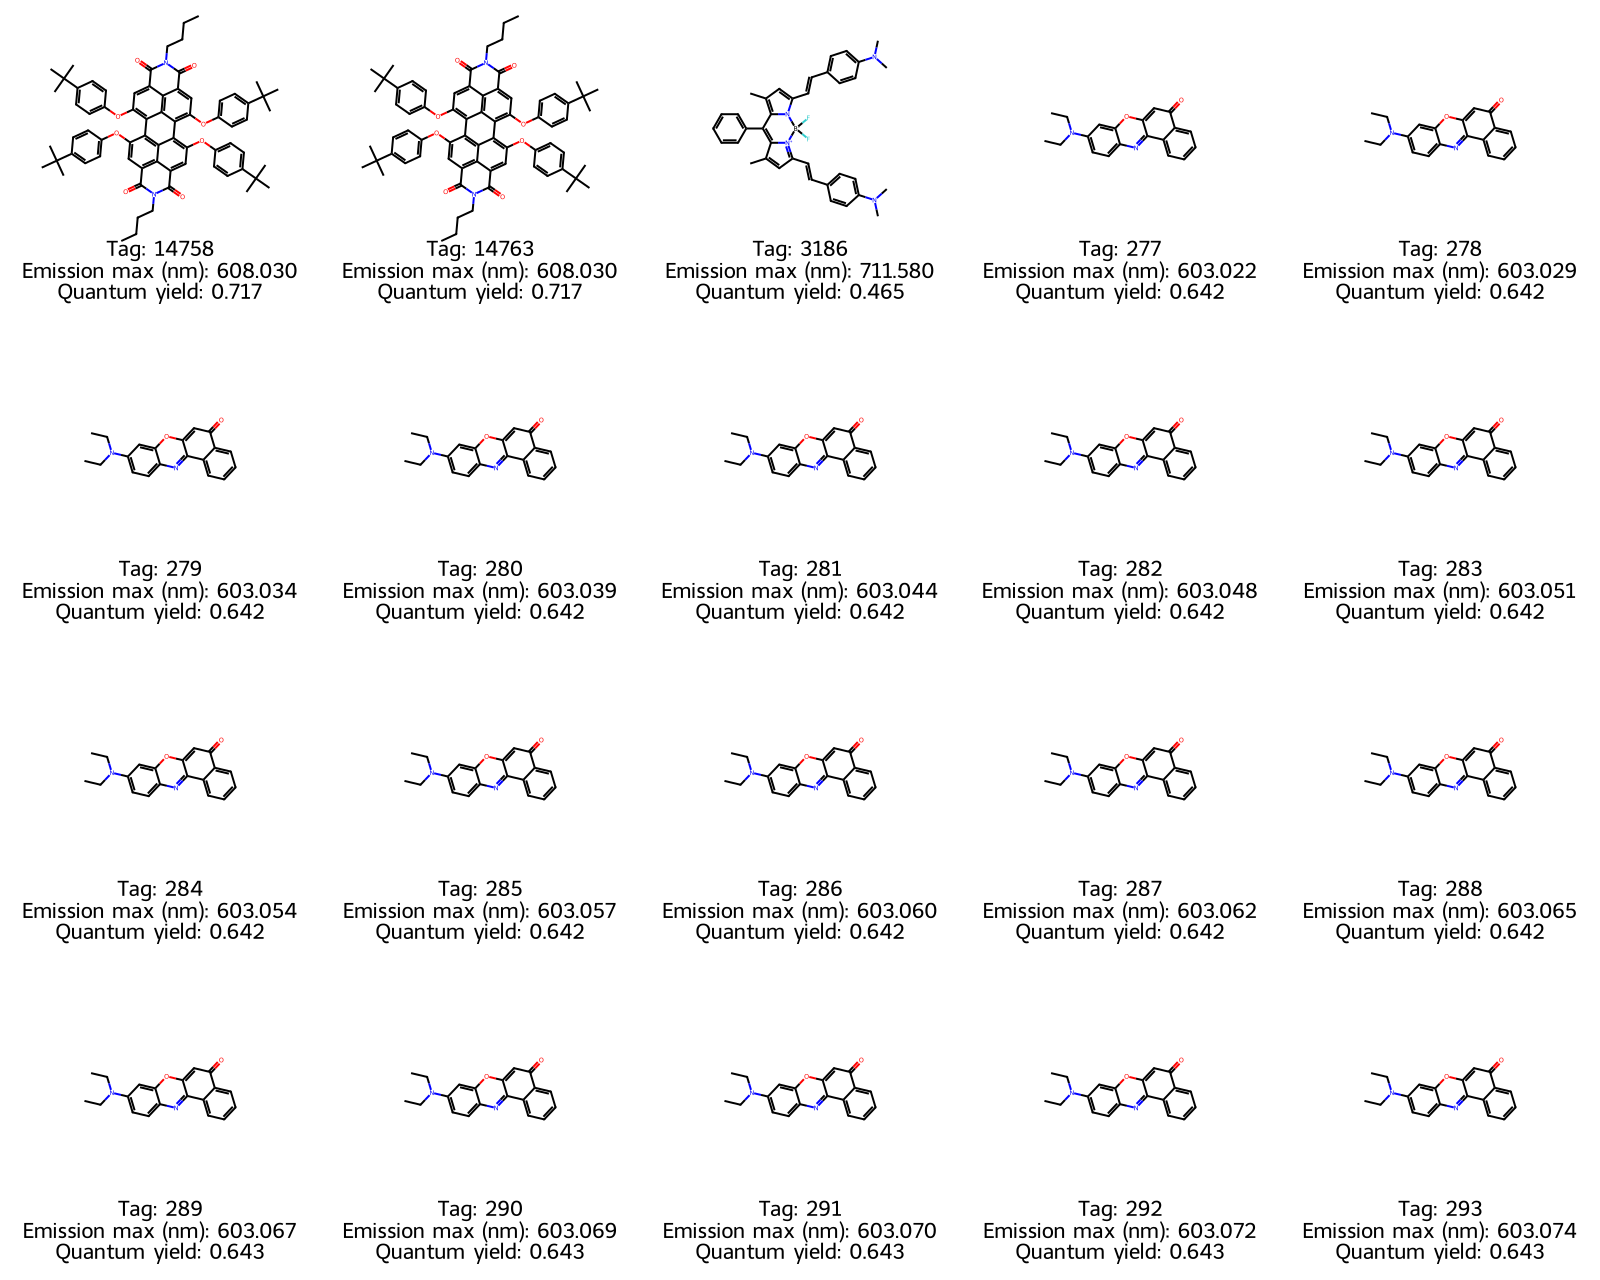

In [11]:
# 選抜候補の化学構造（ループ終了時に Chromophore 付きの bo_selected_summary を利用）

mols = [Chem.MolFromSmiles(s) for s in bo_selected_summary["Chromophore"]]

# 凡例は「選抜ラウンド当時」の予測値（bo_selected_summary）を使う
pred_cols = TARGET_COLS
legends = []
for tag, row in bo_selected_summary.iterrows():
    values = [f"{col}: {row[col]:.3f}" for col in pred_cols]
    legends.append(f"Tag: {tag}\n" + "\n".join(values))

# Legendの設定
options = Draw.MolDrawOptions()
options.legendFontSize = 32
options.legendFraction = 0.22

display(
    Draw.MolsToGridImage(
        mols,
        molsPerRow=5,
        subImgSize=(320, 320),
        legends=legends,
        drawOptions=options
    )
)

In [12]:
# 保存済みサマリーの確認（Chromophore 付き CSV はループ終了セルで出力済み）
print(f"{save_dir}/bo_selected_summary_multi_y_{csv_name_suffix}.csv")
display(bo_selected_summary)

outputs/result/bo_multi_y/bo_selected_summary_multi_y_gpr_one_kernel_PTR.csv


,Emission max (nm),Quantum yield,std_of_emission,std_of_plqy,PTR_emission,PTR_plqy,joint_target_prob_indep,sum_log_target_prob,Chromophore
tag,,,,,,,,,
14758,608.029649,0.716693,38.953175,0.215463,0.581658,0.748447,0.435340,-0.831628,CCCCN1C(=O)c2cc(Oc3ccc(C(C)(C)C)cc3)c3c4c(Oc5c...
14763,608.029893,0.716774,34.987563,0.196986,0.590763,0.789187,0.466222,-0.763092,CCCCN1C(=O)c2cc(Oc3ccc(C(C)(C)C)cc3)c3c4c(Oc5c...
3186,711.580130,0.465141,52.037534,0.263871,0.983846,0.426118,0.419234,-0.869325,CC1=CC(/C=C/c2ccc(N(C)C)cc2)=[N+]2C1=C(c1ccccc...
277,603.021723,0.641665,32.987359,0.186818,0.536493,0.748316,0.401466,-0.912632,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1
278,603.028646,0.641795,32.161170,0.182525,0.537513,0.756524,0.406642,-0.899822,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1
279,603.034436,0.641906,31.613159,0.179613,0.538234,0.762163,0.410222,-0.891056,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1
280,603.039432,0.642002,31.220034,0.177489,0.538778,0.766316,0.412874,-0.884613,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1
281,603.044031,0.642087,30.921635,0.175858,0.539210,0.769531,0.414939,-0.879625,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1
282,603.047831,0.642162,30.686137,0.174556,0.539559,0.772116,0.416602,-0.875624,CCN(CC)c1ccc2nc3c4ccccc4c(=O)cc-3oc2c1
